In [1]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

### Question 1

In [3]:
# question (a)
df = pd.read_csv("problem1.csv")
x = df["x"].dropna().values
n = len(x)

mean = np.mean(x)
var = np.var(x, ddof=1)          
std = np.sqrt(var)
skew = stats.skew(x, bias=False)
kurt = stats.kurtosis(x, bias=False)

print(f"n                 = {n}")
print(f"mean              = {mean:.6f}")
print(f"variance          = {var:.6f}")
print(f"std dev           = {std:.6f}")
print(f"skewness          = {skew:.6f}")
print(f"excess kurtosis   = {kurt:.6f}")


n                 = 1000
mean              = 0.001104
variance          = 0.000096
std dev           = 0.009811
skewness          = -0.669837
excess kurtosis   = 2.357614


In [4]:
# question (b)
q01 = stats.norm.ppf(0.01, loc=mean, scale=std)
observed_below = np.sum(x < q01)
expected_below = 0.01 * n

print(f"\nFitted Normal 1% quantile = {q01:.6f}")
print(f"Observed number below q01 = {observed_below}")
print(f"Expected number below q01 = {expected_below}")


Fitted Normal 1% quantile = -0.021719
Observed number below q01 = 26
Expected number below q01 = 10.0


In [5]:
print("\n--- Left tail ---")
for p in [0.001, 0.005, 0.01, 0.02, 0.05]:
    qn = stats.norm.ppf(p, loc=mean, scale=std)
    obs = np.sum(x < qn)
    exp = p * n
    print(f"p={p:<6} normal_q={qn:>10.5f}  observed={obs:<5} expected={exp:.2f}")

print("\n--- Right tail ---")
for p in [0.95, 0.99, 0.995, 0.999]:
    qn = stats.norm.ppf(p, loc=mean, scale=std)
    obs = np.sum(x > qn)
    exp = (1 - p) * n
    print(f"p={p:<6} normal_q={qn:>10.5f}  observed_above={obs:<5} expected={exp:.2f}")


--- Left tail ---
p=0.001  normal_q=  -0.02921  observed=9     expected=1.00
p=0.005  normal_q=  -0.02417  observed=18    expected=5.00
p=0.01   normal_q=  -0.02172  observed=26    expected=10.00
p=0.02   normal_q=  -0.01904  observed=34    expected=20.00
p=0.05   normal_q=  -0.01503  observed=50    expected=50.00

--- Right tail ---
p=0.95   normal_q=   0.01724  observed_above=34    expected=50.00
p=0.99   normal_q=   0.02393  observed_above=6     expected=10.00
p=0.995  normal_q=   0.02637  observed_above=5     expected=5.00
p=0.999  normal_q=   0.03142  observed_above=3     expected=1.00


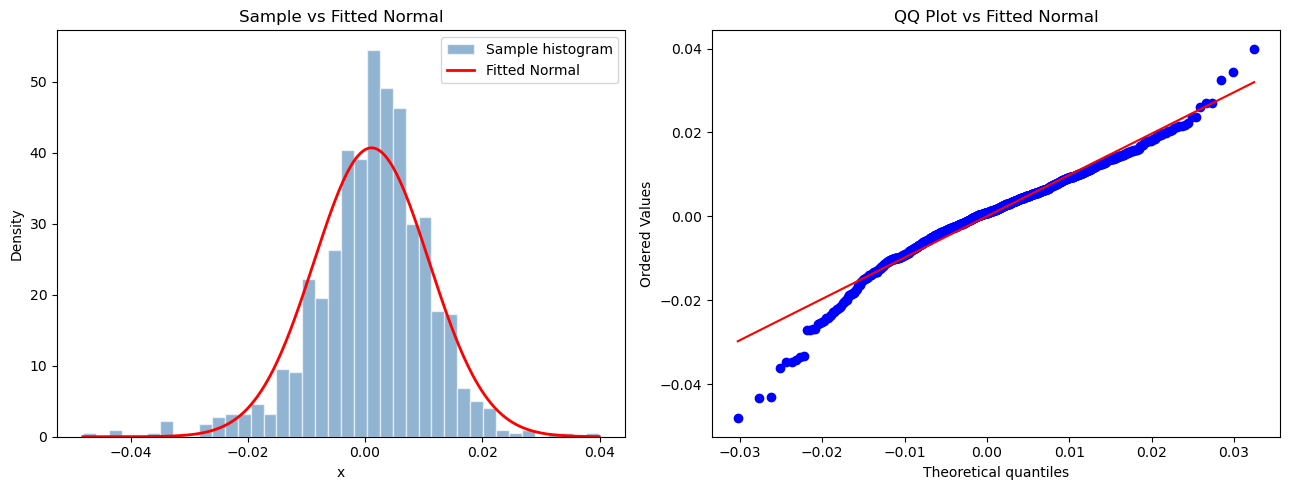

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel 1: Histogram + fitted Normal PDF ---
axes[0].hist(x, bins=40, density=True, alpha=0.6, color='steelblue',
             edgecolor='white', label='Sample histogram')
xs = np.linspace(x.min(), x.max(), 500)
axes[0].plot(xs, stats.norm.pdf(xs, mean, std), 'r-', lw=2, label='Fitted Normal')
axes[0].set_title('Sample vs Fitted Normal')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].legend()
# --- Panel 2: QQ plot vs fitted Normal ---
stats.probplot(x, dist=stats.norm, sparams=(mean, std), plot=axes[1])
axes[1].set_title('QQ Plot vs Fitted Normal')

plt.tight_layout()
plt.savefig("figures/normal_fit_plot.png", dpi=150)
plt.show()


### Question 2

In [8]:
df2 = pd.read_csv("problem2.csv")
df2

,x,y
0,0.552447,3.351035
1,-1.245128,-1.966928
2,0.905569,5.632345
3,0.681733,4.292113
4,-0.159037,0.538857
...,...,...
195,-0.530134,-0.267827
196,0.741086,4.335538
197,0.800139,2.204162
198,1.182714,5.191477


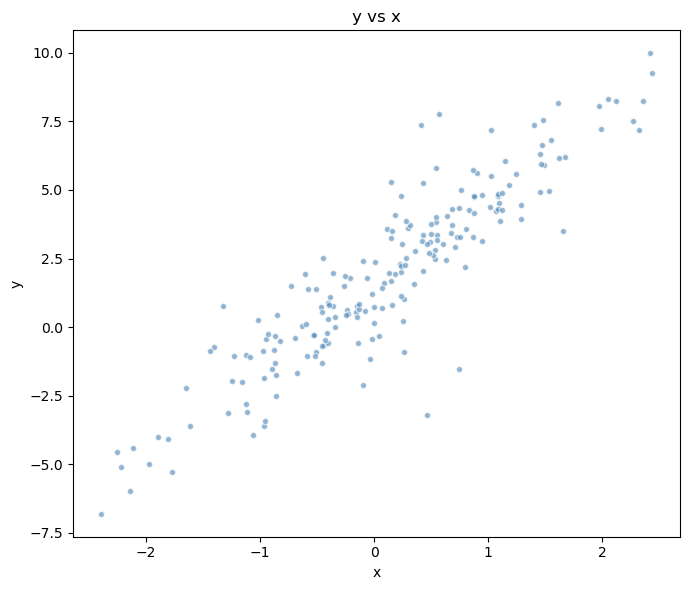

In [9]:
x = df2['x']
y = df2['y']

plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, s=20, color='steelblue', edgecolor='white')
plt.xlabel("x")
plt.ylabel("y")
plt.title("y vs x")
plt.tight_layout()
plt.savefig("figures/y_vs_x_scatter.png", dpi=150)
plt.show()


In [10]:
from scipy.optimize import minimize
import statsmodels.api as sm
X = sm.add_constant(x)

n2 = len(x)

# Model 1: OLS
ols = sm.OLS(y, X).fit()
alpha_ols, beta_ols = ols.params
se_alpha_ols, se_beta_ols = ols.bse
sigma_ols = np.sqrt(ols.mse_resid)

print("1. OLS")
print(f"alpha (intercept) = {alpha_ols:.4f}, SE = {se_alpha_ols:.4f}")
print(f"beta (slope)      = {beta_ols:.4f}, SE = {se_beta_ols:.4f}")
print(f"sigma (resid std) = {sigma_ols:.4f}")
print()

# Model 2: MLE under Normal errors
def neg_ll_normal(params):
    a, b, sigma = params
    if sigma <= 0:
        return 1e10
    resid = y - (a + b * x)
    return -np.sum(stats.norm.logpdf(resid, loc=0, scale=sigma))

res_norm = minimize(neg_ll_normal, x0=[0, 1, 1], method="Nelder-Mead")
a_n, b_n, sigma_n = res_norm.x
ll_norm = -res_norm.fun

k_norm = 3  # alpha, beta, sigma
aic_norm = 2 * k_norm - 2 * ll_norm
aicc_norm = aic_norm + (2 * k_norm * (k_norm + 1)) / (n2 - k_norm - 1)

print("2. MLE Normal")
print(f"alpha = {a_n:.4f}, beta = {b_n:.4f}, sigma = {sigma_n:.4f}")
print(f"log-likelihood = {ll_norm:.4f}")
print(f"AIC = {aic_norm:.4f}, AICc = {aicc_norm:.4f}")
print()


# Model 3: MLE under Student's t errors
def neg_ll_t(params):
    a, b, scale, nu = params
    if scale <= 0 or nu <= 2.01:
        return 1e10
    resid = y - (a + b * x)
    return -np.sum(stats.t.logpdf(resid / scale, df=nu) - np.log(scale))

res_t = minimize(
    neg_ll_t,
    x0=[alpha_ols, beta_ols, sigma_ols, 5],
    method="Nelder-Mead",
    options={"maxiter": 20000, "xatol": 1e-8, "fatol": 1e-8},
)
a_t, b_t, scale_t, nu_t = res_t.x
ll_t = -res_t.fun

k_t = 4  # alpha, beta, scale, nu
aic_t = 2 * k_t - 2 * ll_t
aicc_t = aic_t + (2 * k_t * (k_t + 1)) / (n2 - k_t - 1)

print("3. MLE Student t")
print(f"alpha = {a_t:.4f}, beta = {b_t:.4f}, scale = {scale_t:.4f}, nu (df) = {nu_t:.4f}")
print(f"log-likelihood = {ll_t:.4f}")
print(f"AIC = {aic_t:.4f}, AICc = {aicc_t:.4f}")
print()


# Model comparison via AICc
print("=== AICc comparison ===")
print(f"Normal AICc:    {aicc_norm:.4f}")
print(f"Student-t AICc: {aicc_t:.4f}")

if aicc_t < aicc_norm:
    print("-> Student's t error model preferred (lower AICc).")
else:
    print("-> Normal error model preferred (lower AICc).")


1. OLS
alpha (intercept) = 1.5607, SE = 0.0963
beta (slope)      = 2.9908, SE = 0.0966
sigma (resid std) = 1.3514

2. MLE Normal
alpha = 1.5607, beta = 2.9907, sigma = 1.3446
log-likelihood = -343.0110
AIC = 692.0221, AICc = 692.1445

3. MLE Student t
alpha = 1.5480, beta = 3.0192, scale = 0.9355, nu (df) = 3.6322
log-likelihood = -328.5612
AIC = 665.1224, AICc = 665.3275

=== AICc comparison ===
Normal AICc:    692.1445
Student-t AICc: 665.3275
-> Student's t error model preferred (lower AICc).


In [11]:
#Quantile Comparison

for p in [0.95, 0.995]:

    # Normal error quantile
    q_normal = stats.norm.ppf(p, loc=0, scale=sigma_n)

    # Student-t error quantile
    q_t = stats.t.ppf(p, df=nu_t, loc=0, scale=scale_t)

    print(f"{p*100:.1f}% quantile:")
    print(f"  Normal:    {q_normal:.4f}")
    print(f"  Student-t: {q_t:.4f}")

95.0% quantile:
  Normal:    2.2117
  Student-t: 2.0538
99.5% quantile:
  Normal:    3.4636
  Student-t: 4.6201


### Question 3

In [13]:
df3 = pd.read_csv("problem3.csv")
df3

,x1,x2,x3,x4
0,-1.383645,-2.686309,-1.371254,0.396672
1,0.095933,0.013816,-0.723778,-1.028177
2,1.325026,2.367298,-0.009454,2.799896
3,-1.718078,-5.102044,-2.278599,0.544008
4,0.502742,0.093502,-0.151283,1.095976
...,...,...,...,...
495,-1.126383,-1.460247,-0.980298,-0.279709
496,-0.916796,-0.804090,-1.086874,-0.365765
497,-1.105081,-1.329467,-1.111287,0.391021
498,1.611456,4.111766,1.399849,0.622259


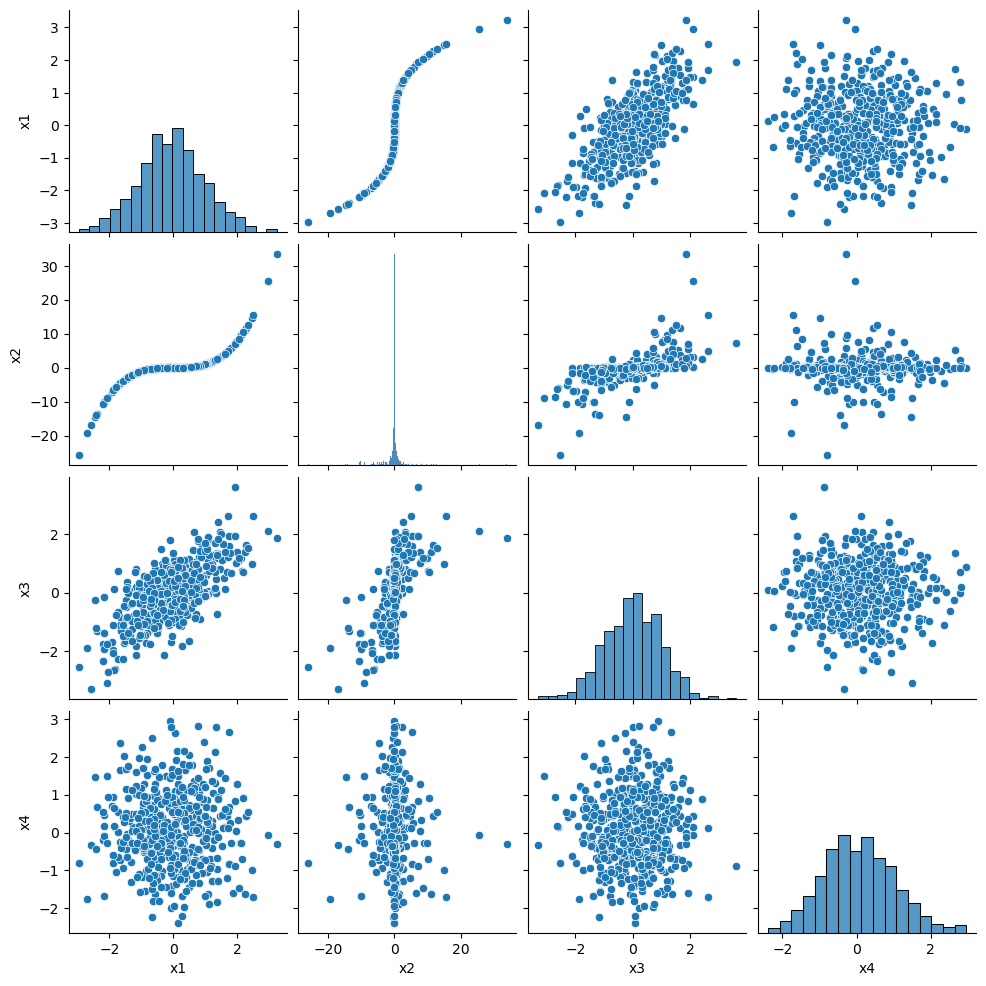

In [14]:
import seaborn as sns

# Plot every pair
sns.pairplot(df3[['x1', 'x2', 'x3', 'x4']])
plt.show()

In [15]:
# Pearson correlation matrix
pearson_corr = df3.corr(method='pearson')

# Spearman correlation matrix
spearman_corr = df3.corr(method='spearman')

print("---Pearson Correlation Matrix---")
print(pearson_corr)
print("---Spearman Correlation Matrix---")
print(spearman_corr)

---Pearson Correlation Matrix---
          x1        x2        x3        x4
x1  1.000000  0.799092  0.719467 -0.004680
x2  0.799092  1.000000  0.587614 -0.020923
x3  0.719467  0.587614  1.000000 -0.008605
x4 -0.004680 -0.020923 -0.008605  1.000000
---Spearman Correlation Matrix---
          x1        x2        x3        x4
x1  1.000000  0.971930  0.683910  0.000189
x2  0.971930  1.000000  0.667422 -0.001131
x3  0.683910  0.667422  1.000000 -0.002422
x4  0.000189 -0.001131 -0.002422  1.000000


### Question 4

In [17]:
df4 = pd.read_csv("problem4.csv")
df4

,x1,x2
0,-0.551088,-0.896356
1,0.892005,1.640851
2,0.218606,-0.842202
3,-1.068407,1.759723
4,-0.551480,0.050912
...,...,...
995,-0.577232,-0.152179
996,-0.044740,0.195028
997,0.691167,-1.273001
998,1.395019,2.486829


In [18]:
cov_matrix = df4[['x1','x2']].cov()

print("Sample covariance matrix:")
print(cov_matrix)

Sample covariance matrix:
          x1        x2
x1  1.099875  1.696902
x2  1.696902  4.104749


In [19]:
import pandas as pd
import numpy as np

# Load data
df4 = pd.read_csv("problem4.csv")

x1 = df4["x1"]
x2 = df4["x2"]

# Means
mu1 = x1.mean()
mu2 = x2.mean()

# Covariance matrix
Sigma = df4[["x1", "x2"]].cov()

# Blocks of Sigma
Sigma11 = Sigma.loc["x1", "x1"]
Sigma12 = Sigma.loc["x1", "x2"]
Sigma21 = Sigma.loc["x2", "x1"]
Sigma22 = Sigma.loc["x2", "x2"]

beta = Sigma21 / Sigma11
conditional_mean = mu2 + beta * (x1 - mu1)
conditional_var = Sigma22 - Sigma21 * (1 / Sigma11) * Sigma12
conditional_sd = np.sqrt(conditional_var)

# 95% band AT EACH OBSERVED x1
lower = conditional_mean - 1.96 * conditional_sd
upper = conditional_mean + 1.96 * conditional_sd

inside = (x2 >= lower) & (x2 <= upper)

# Fraction inside
num_inside = inside.sum()
num_total = len(df4)
fraction = num_inside / num_total

print("Conditional mean coefficient:", beta)
print("Conditional variance:", conditional_var)
print("Conditional standard deviation:", conditional_sd)
print("Fraction inside:", fraction)


Conditional mean coefficient: 1.5428133384439877
Conditional variance: 1.4867456782952875
Conditional standard deviation: 1.2193218108011057
Fraction inside: 0.935


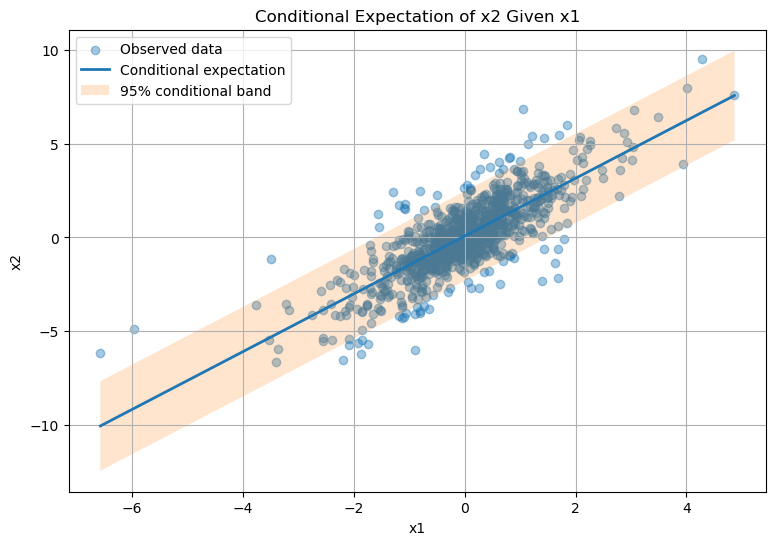

In [20]:
x1_grid = np.linspace(x1.min(), x1.max(), 300)

# Conditional expectation evaluated over the grid
conditional_mean_grid = mu2 + beta * (x1_grid - mu1)

# 95% conditional interval
upper_grid = conditional_mean_grid + 1.96 * conditional_sd
lower_grid = conditional_mean_grid - 1.96 * conditional_sd

# Plot observed data
plt.figure(figsize=(9, 6))

plt.scatter(
    x1,
    x2,
    alpha=0.4,
    label="Observed data"
)

# Conditional expectation
plt.plot(
    x1_grid,
    conditional_mean_grid,
    linewidth=2,
    label="Conditional expectation"
)

# 95% conditional band
plt.fill_between(
    x1_grid,
    lower_grid,
    upper_grid,
    alpha=0.2,
    label="95% conditional band"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Conditional Expectation of x2 Given x1")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# 4(e)
# Standard deviation of x1
sd_x1 = x1.std()

# Absolute distance from the mean, measured in standard deviations
z_x1 = np.abs((x1 - mu1) / sd_x1)

inside_1sd = z_x1 <= 1
between_1_2sd = (z_x1 > 1) & (z_x1 <= 2)
beyond_2sd = z_x1 > 2

coverage_1sd = inside[inside_1sd].mean()
coverage_1_2sd = inside[between_1_2sd].mean()
coverage_2sd = inside[beyond_2sd].mean()

n_1sd = inside_1sd.sum()
n_1_2sd = between_1_2sd.sum()
n_2sd = beyond_2sd.sum()

print("\nCoverage by distance of x1 from its mean:")
print(f"Within 1 SD:       {coverage_1sd:.4f} ({coverage_1sd*100:.2f}%), n = {n_1sd}")
print(f"Between 1 and 2 SD: {coverage_1_2sd:.4f} ({coverage_1_2sd*100:.2f}%), n = {n_1_2sd}")
print(f"Beyond 2 SD:       {coverage_2sd:.4f} ({coverage_2sd*100:.2f}%), n = {n_2sd}")



Coverage by distance of x1 from its mean:
Within 1 SD:       0.9565 (95.65%), n = 759
Between 1 and 2 SD: 0.8579 (85.79%), n = 190
Beyond 2 SD:       0.9020 (90.20%), n = 51


### Question 5

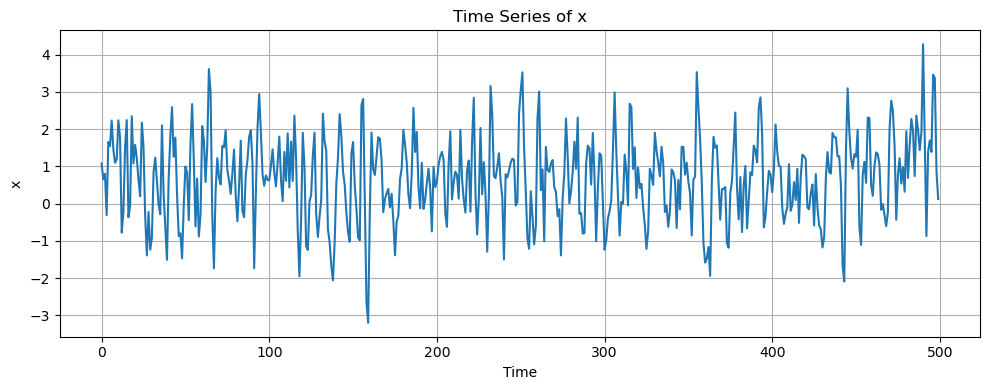

<Figure size 1000x400 with 0 Axes>

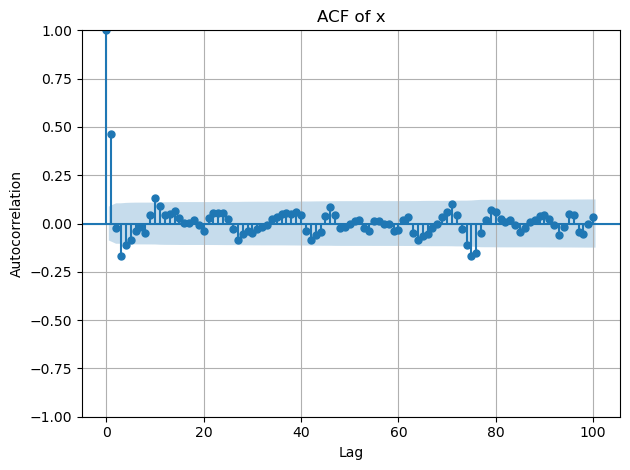

<Figure size 1000x400 with 0 Axes>

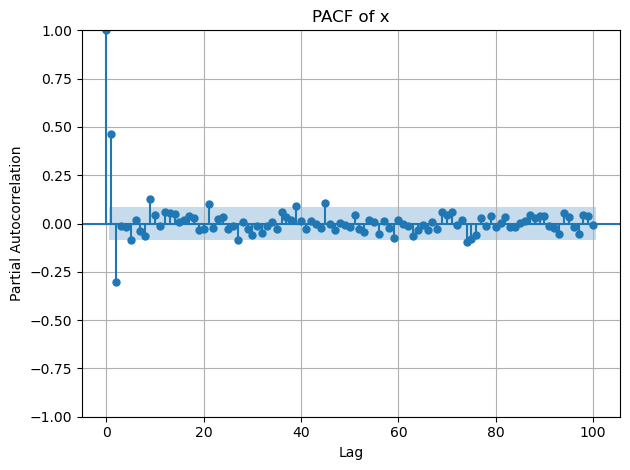

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load the data
df5 = pd.read_csv("problem5.csv")
x = df5["x"].dropna()

n = len(x)

# 1. Plot the time series
plt.figure(figsize=(10, 4))
plt.plot(x)
plt.title("Time Series of x")
plt.xlabel("Time")
plt.ylabel("x")
plt.grid(True)
plt.tight_layout()
plt.show()



# 2. Plot the ACF

plt.figure(figsize=(10, 4))
plot_acf(x, lags=100, alpha=0.05)
plt.title("ACF of x")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.tight_layout()
plt.show()


# 3. Plot the PACF

plt.figure(figsize=(10, 4))
plot_pacf(x, lags=100, alpha=0.05, method="ywm")
plt.title("PACF of x")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

def AICc(model):
    aic = model.aic
    k = len(model.params)     # number of estimated parameters
    nobs = model.nobs         # this model's own effective sample size
    return aic + (2 * k * (k + 1)) / (nobs - k - 1)


# Fit models
models = {}

# AR models
models["AR(1)"] = AutoReg(x, lags=1, trend="c").fit()
models["AR(2)"] = AutoReg(x, lags=2, trend="c").fit()
models["AR(3)"] = AutoReg(x, lags=3, trend="c").fit()

# MA models
models["MA(1)"] = ARIMA(x, order=(0, 0, 1), trend="c").fit()
models["MA(2)"] = ARIMA(x, order=(0, 0, 2), trend="c").fit()
models["MA(3)"] = ARIMA(x, order=(0, 0, 3), trend="c").fit()


# Report AICc
print("AICc for each model:")
print("-" * 30)

for name, model in models.items():
    print(f"{name:6s}: {AICc(model):.4f}")

best_model = min(models, key=lambda m: AICc(models[m]))
print(f"\n-> Lowest AICc: {best_model}")


AICc for each model:
------------------------------
AR(1) : 1416.3654
AR(2) : 1368.3393
AR(3) : 1368.4267
MA(1) : 1389.0843
MA(2) : 1381.2316
MA(3) : 1374.1165

-> Lowest AICc: AR(2)
